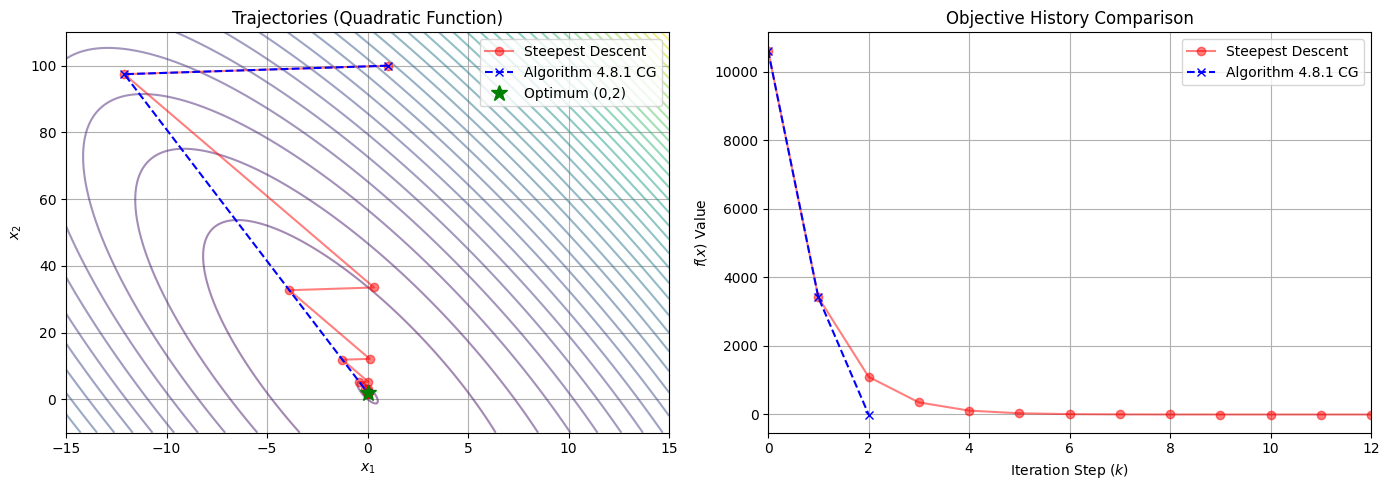

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import rosen, rosen_der

def f_quad(x):
    return 40.0 * x[0]**2 + x[1]**2 + 10.0 * x[0] * x[1] - 20.0 * x[0] - 4.0 * x[1]

H = np.array([[80.0, 10.0], 
              [10.0,  2.0]])
b = np.array([-20.0, -4.0])

def grad_quad(x):
    return np.dot(H, x) + b

def steepest_descent_quadratic(x0, max_iter=200, tol=1e-6):
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    f_vals = [f_quad(x)]
    
    for _ in range(max_iter):
        g = grad_quad(x)
        if np.linalg.norm(g) < tol:
            break
        d = -g 
        
        # exact step size
        sigma = -np.dot(g, d) / np.dot(d, np.dot(H, d))
        x += sigma * d
        
        path.append(x.copy())
        f_vals.append(f_quad(x))
    return np.array(path), np.array(f_vals)

def conjugate_gradient_algorithm_481(x0, max_iter=200, tol=1e-6):
    
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    f_vals = [f_quad(x)]
    
    g = grad_quad(x)
    d = -g
    
    for k in range(max_iter):
        if np.linalg.norm(g) < tol:
            break
            
        Hd = np.dot(H, d)
        g_norm_sq = np.dot(g, g)
        
        sigma = g_norm_sq / np.dot(d, Hd)
        
        # Position update
        x = x + sigma * d
        path.append(x.copy())
        f_vals.append(f_quad(x))
        
        g_next = g + sigma * Hd
        if np.linalg.norm(g_next) < tol:
            break
  
        beta = np.dot(g_next, g_next) / g_norm_sq
        
        d = -g_next + beta * d
        g = g_next
        
    return np.array(path), np.array(f_vals)


# Part b
def armijo_backtrack(x, d, g, delta=1e-4, beta=0.5):
    t = 1.0
    f_x = rosen(x)
    dir_der = np.dot(g, d)
    while rosen(x + t * d) > f_x + delta * t * dir_der:
        t *= beta
        if t < 1e-12:
            break
    return t

def fletcher_reeves_cg(x0, max_iter=1000, tol=1e-5):
    x = np.array(x0, dtype=float)
    path, f_vals = [x.copy()], [rosen(x)]
    g = rosen_der(x)
    d = -g
    
    for _ in range(max_iter):
        if np.linalg.norm(g) < tol:
            break
        t = armijo_backtrack(x, d, g)
        x += t * d
        path.append(x.copy())
        f_vals.append(rosen(x))
        
        g_next = rosen_der(x)
        if np.linalg.norm(g_next) < tol:
            break
        beta = np.dot(g_next, g_next) / np.dot(g, g)
        d = -g_next + beta * d
        
        if np.dot(g_next, d) >= 0:  # Restart check
            d = -g_next
        g = g_next
    return np.array(path), np.array(f_vals)

# Visualisation
if __name__ == "__main__":
    x0_q = np.array([1.0, 100.0])
    path_sd, f_sd = steepest_descent_quadratic(x0_q)
    path_cg, f_cg = conjugate_gradient_algorithm_481(x0_q)
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    x1_g, x2_g = np.linspace(-15, 15, 300), np.linspace(-10, 110, 300)
    X, Y = np.meshgrid(x1_g, x2_g)
    Z = 40.0 * X**2 + Y**2 + 10.0 * X * Y - 20.0 * X - 4.0 * Y
    
    axs[0].contour(X, Y, Z, levels=40, cmap='viridis', alpha=0.5)
    axs[0].plot(path_sd[:, 0], path_sd[:, 1], 'ro-', label='Steepest Descent', alpha=0.5)
    axs[0].plot(path_cg[:, 0], path_cg[:, 1], 'bx--', label='CG')
    axs[0].plot(0.0, 2.0, 'g*', markersize=12, label='Optimum (0,2)')
    axs[0].set_title("Trajectories (Quadratic Function)")
    axs[0].set_xlabel("$x_1$")
    axs[0].set_ylabel("$x_2$")
    axs[0].legend()
    axs[0].grid(True)
    
    axs[1].plot(f_sd, 'ro-', label='Steepest Descent', alpha=0.5)
    axs[1].plot(f_cg, 'bx--', label='Algorithm 4.8.1 CG')
    axs[1].set_xlim(0, 12)
    axs[1].set_title("Objective History Comparison")
    axs[1].set_xlabel("Iteration Step ($k$)")
    axs[1].set_ylabel("$f(x)$ Value")
    axs[1].legend()
    axs[1].grid(True)
    plt.tight_layout()
    plt.show()